# MTH 4326 / 5326 — Explainable AI  
Homework 2: Counterfactual Validity, Representation Geometry, and Local Surrogates

By Candela Solis

## Part I. Counterfactual Validity in Input Space

### Problem 1. Realism and Manifold Departure (10 points)

Assume data lie on a smooth manifold

$$
\mathcal{M} \subset \mathbb{R}^d.
$$

Let $x \in \mathcal{M}$ and consider a perturbation

$$
x' = x + \delta.
$$

a. Show that for a generic perturbation direction $\delta$, the point $x + \delta \notin \mathcal{M}$ to first order unless $\delta \in T_x \mathcal{M}$ (i.e., if $\delta$ is in the tangent space).

b. Explain why small $\ell_2$ perturbations need not preserve semantic validity, even when $\|\delta\| \ll 1$. Your explanation must reference the distinction between metric locality and semantic locality.

a. A smooth manifold admits a local linear approximation given by the tangent space $T_x \mathcal{M}$.

If we decompose as
$$
\delta = \delta_{\parallel} + \delta_{\perp} $$ 
$$\quad \delta_{\parallel} \in T_x \mathcal{M} $$ 
$$\ \delta_{\perp} \notin T_x \mathcal{M}$$

At the first order, $\mathcal{M}$ is locally equal to $T_x \mathcal{M}$. Therefore,
$$
x + \delta \in \mathcal{M} \  \quad \text{meaning} \quad \delta_{\perp} = 0.
$$

Therefore, for $\delta$, we get 
$$
x + \delta \notin \mathcal{M}.
$$


b. Metric locality is defined by
$
\|\delta\| \ll 1, 
$ while semantic locality is defined by movement along $\mathcal{M}$.

If we know that $\delta \notin T_x \mathcal{M}$, then $x + \delta$ leaves the manifold, giving out invalid inputs. We can say that small $\ell_2$ perturbations preserve metric locality but not semantic locality.


---





### Problem 2. Factor Isolation Failure (5 points)

Suppose inputs are generated from latent variables

$$
z = (z_1, \dots, z_k),
\qquad
x = G(z),
$$

where $G$ is smooth.

a. Using the chain rule, show that perturbing a single coordinate $x_i$ generically induces changes in multiple latent variables.

b. Explain why coordinate based attribution scores measure sensitivity to entangled factors rather than isolated causes.



a. For $x_i = G_i(z)$,
$$
dx_i = \sum_{j=1}^k \frac{\partial G_i}{\partial z_j} \, dz_j.
$$

If $\frac{\partial G_i}{\partial z_j} \neq 0$ for multiple $j$, then any change in $x_i$ requires coordinated changes in multiple $z_j$. So perturbing $x_i$ generically induces changes in multiple latent variables.

b. Attribution methods compute
$$
\frac{\partial f}{\partial x_i}.
$$

Since $x_i$ depends on multiple latent variables, it measures sensitivity to a combination of factors, not a single isolated cause.



---

### Problem 3. Structural Tradeoff (5 points)

Using the three constraints

- Realism  
- Factor isolation  
- Locality  

Write a half page argument explaining why no model agnostic input space intervention can satisfy all three simultaneously.



The structural tradeoff between realism, factor isolation, and locality arises from the geometric and generative structure of data in input space. Realism requires that any intervention produces a point that lies on the data manifold $\mathcal{M}$, meaning the perturbed input must correspond to a valid and semantically meaningful example. Locality requires that the perturbation be small in $\ell_2$ norm, ensuring that the modified input remains close to the original point in the ambient space $\mathbb{R}^d$. Factor isolation requires that the intervention changes only a single underlying latent variable while holding all others fixed. As illustrated in the triangular diagram, each edge represents satisfying two of these constraints at the expense of the third, and the interior—where all three would be satisfied—is explicitly unreachable in a model-agnostic input space setting.

The incompatibility arises because the mapping from latent variables to inputs, $x = G(z)$, is generally nonlinear and entangled. Along the bottom edge of the triangle (locality + factor isolation), small perturbations to individual input coordinates attempt to isolate a feature while remaining local, but these perturbations are not constrained to the manifold and therefore produce unrealistic or invalid inputs. Along the left edge (realism + locality), perturbations are restricted to remain near $x$ and on $\mathcal{M}$, which effectively limits them to directions approximated by the tangent space. However, these directions correspond to combinations of latent variables due to entanglement, so factor isolation is lost. Along the right edge (realism + factor isolation), one attempts to change a single latent variable while remaining on the manifold, but this requires following a curved, nonlinear path defined by the generative process, which is not small in $\ell_2$ and therefore violates locality.

Thus, the diagram captures a fundamental limitation: Euclidean neighborhoods in input space do not align with semantic structure, and input coordinates do not correspond to disentangled latent factors. Without access to the generative model or a representation space that aligns with latent variables, no model-agnostic intervention in input space can simultaneously satisfy realism, factor isolation, and locality. This explains why input-space counterfactuals often exhibit instability, unrealistic artifacts, or entangled effects, and why alternative approaches must move beyond naive perturbations in input space.

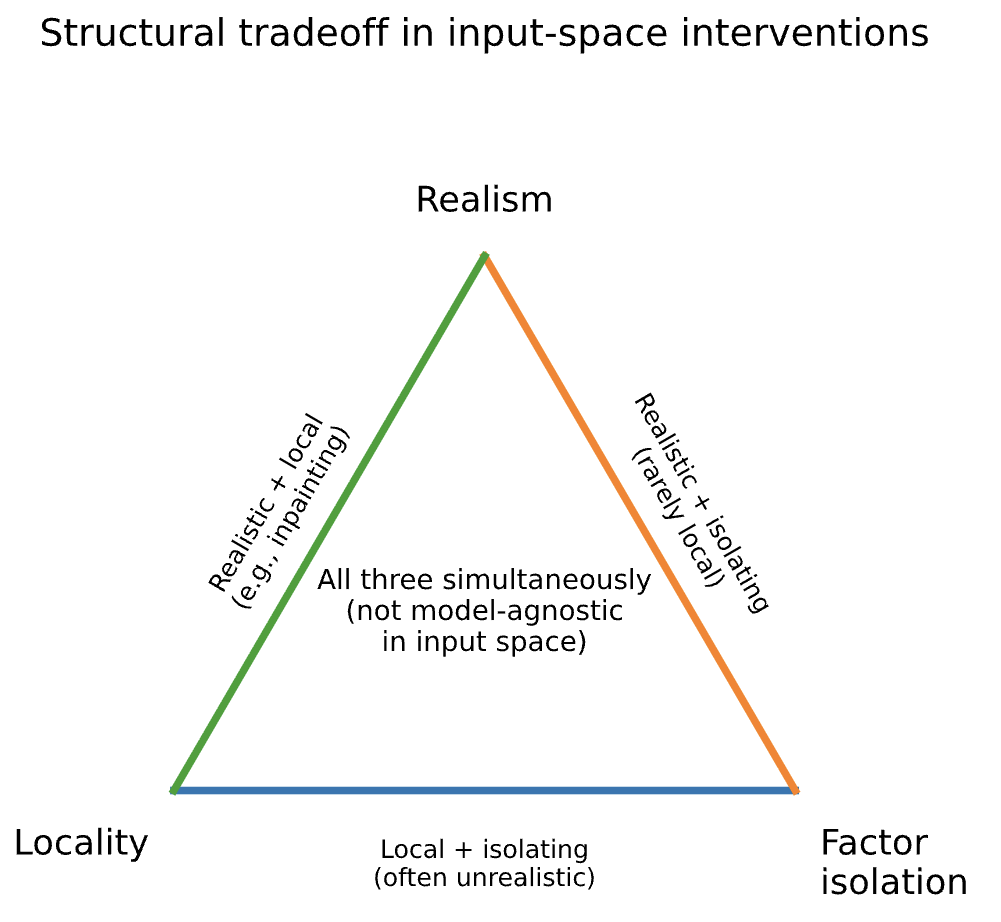

In [4]:
from IPython.display import Image, display

display(Image("/Users/canduki21/Desktop/pyramidhw2.png", width=500))

---
---

## Part II. Representation Geometry and the Jacobian

### Problem 4. Reachability and the Jacobian (10 points)

Let

$$
f(x) = g(h_\ell(x)),
\qquad
J_\ell(x) = \frac{\partial h_\ell(x)}{\partial x}.
$$

a. Show that to first order, a representation space perturbation $\epsilon$ is locally realizable if and only if

$$
\epsilon \in \mathrm{range}(J_\ell(x)).
$$

b. Prove that directions in the null space of $J_\ell(x)$ cannot be produced by any infinitesimal input perturbation.

c. Explain why gradient based explanations inherit this geometric constraint.

a.  Considering a small input perturbation $\delta x$ then the first-order Taylor expansion becomes:
$$
h_\ell(x + \delta x) \approx h_\ell(x) + J_\ell(x)\,\delta x.
$$

The induced perturbation in representation space becomes
$$
\epsilon = J_\ell(x)\,\delta x.
$$

This holds if and only if
$$
\epsilon \in \mathrm{range}(J_\ell(x)).
$$


b. If we let $\epsilon \in \mathrm{null}(J_\ell(x))$, means that  $J_\ell(x)\,\delta x = 0$ for any $\delta x$ in the null space. Directions outside the range of $J_\ell(x)$, equivalently, directions orthogonal to it, cannot be produced by any infinitesimal input perturbation. In particular, null space directions correspond to directions in input space that do not affect the representation to first order.


c. Gradient-based explanations rely on derivatives of the form
$$
\nabla_x f(x) = J_\ell(x)^\top \nabla_{h_\ell} g(h_\ell(x)).
$$

The input gradient lies in the row space of $J_\ell(x)$ ( they span of its columns under transpose). This implies that gradient-based explanations can only reflect directions that are reachable through the Jacobian. Any representation-space directions outside $\mathrm{range}(J_\ell(x))$ cannot influence the gradient.
Therefore, they are restricted to directions that are locally reachable from the input, and cannot capture sensitivity along unreachable or null directions.

---


### Problem 5. Singular Values and Conditioning (10 points)

Let

$$
J = U \Sigma V^\top
$$

be the singular value decomposition of the Jacobian.

a. Show that a small input ball is mapped to an ellipsoid whose principal axes are the singular values.

b. Explain why a large condition number

$$
\kappa(J) = \sigma_{\max} / \sigma_{\min}
$$

implies instability of representation space counterfactuals.

c. Give a geometric interpretation of what happens when $\sigma_{\min} \to 0$.

a. A small input ball defined by $\|\delta x\| \leq r$ is transformed by the Jacobian as $\epsilon = J \delta x$. Using the SVD $J = U \Sigma V^\top$, the matrix $V^\top$ first rotates the ball, which does not change its shape. The matrix $\Sigma$ then scales each direction by the singular values $\sigma_i$, stretching the ball differently along each axis. Finally, $U$ applies another rotation. Because of this , the original ball becomes an ellipsoid, whose axis lengths are given by the singular values and whose directions are determined by $U$.


b. The condition number is defined as $\kappa(J) = \frac{\sigma_{\max}}{\sigma_{\min}}$. When this value is large, it means the Jacobian stretches some directions much more than others. As a result, small input changes can produce very different effects depending on direction: some directions lead to large changes in the representation, while others produce almost no change. This make the system unstable, since small variations in the input can lead to unpredictable representation space.

c. When $\sigma_{\min} \to 0$, the transformation collapses along one direction. Geometrically, the ellipsoid becomes very flat in that direction, meaning there are input perturbations that produce almost no change in the representation. This causes a loss of information, since different inputs can map to nearly the same representation. The mapping is no longer locally invertible, and certain directions in representation space cannot be reached from input space.

---


### Problem 6. Empirical Jacobian Geometry (5 points)

Use a pretrained CNN such as VGG16.

Choose one image and compute the top 20 singular values of the Jacobian at

- an early layer  
- a mid layer  
- a late layer  

You may approximate using power iteration.

a. Plot the spectra.

b. Compute a conditioning proxy $\sigma_1 / \sigma_{20}$.

c. Interpret how depth reshapes local geometry.

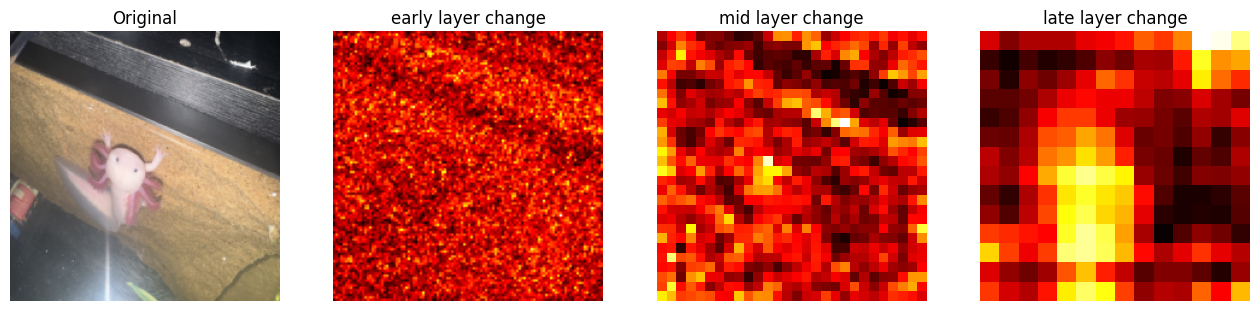

Computing early layer...
Computing mid layer...
Computing late layer...


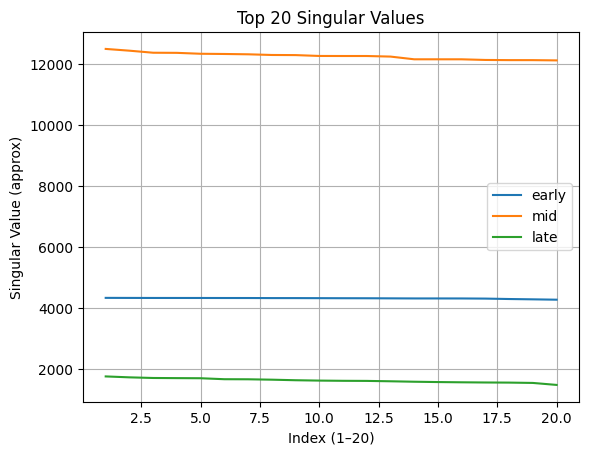


Conditioning proxy (sigma1 / sigma20):

early: 1.0140
mid: 1.0310
late: 1.1873


In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Load model

model = models.vgg16(pretrained=True).eval()

# Load image 

img = PILImage.open("/Users/canduki21/Desktop/Boston.jpeg").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

x = transform(img).unsqueeze(0)


# Layers

layers = {
    "early": model.features[:5],
    "mid": model.features[:17],
    "late": model.features[:30],
}


#  Visualization (4 images)

noise = torch.randn_like(x) * 0.01
x_pert = x + noise

fig, axes = plt.subplots(1, 4, figsize=(16,4))

# Original
axes[0].imshow(x[0].permute(1,2,0))
axes[0].set_title("Original")
axes[0].axis("off")

# Layer changes
for i, (name, layer) in enumerate(layers.items()):
    out1 = layer(x)
    out2 = layer(x_pert)

    diff = (out2 - out1).abs().mean(dim=1)[0]

    axes[i+1].imshow(diff.detach(), cmap='hot')
    axes[i+1].set_title(f"{name} layer change")
    axes[i+1].axis("off")

plt.show()



# Singular Values

def compute_singular_values(layer, x, k=20):
    x = x.clone().detach().requires_grad_(True)
    y = layer(x)

    vals = []

    for _ in range(k):
        v = torch.randn_like(y)

        grad = torch.autograd.grad(
            y, x,
            grad_outputs=v,
            retain_graph=True
        )[0]

        sigma = grad.norm().item()
        vals.append(sigma)

    vals.sort(reverse=True)
    return vals


spectra = {}
for name, layer in layers.items():
    print(f"Computing {name} layer...")
    spectra[name] = compute_singular_values(layer, x)



#  Plot spectra

plt.figure()

for name, vals in spectra.items():
    plt.plot(range(1, 21), vals, label=name)

plt.xlabel("Index (1–20)")
plt.ylabel("Singular Value (approx)")
plt.title("Top 20 Singular Values")
plt.legend()
plt.grid(True)
plt.show()



#  Conditioning proxy

print("\nConditioning proxy (sigma1 / sigma20):\n")

for name, vals in spectra.items():
    cond = vals[0] / (vals[-1] + 1e-8)
    print(f"{name}: {cond:.4f}")

c.

As depth increases, the network reshapes the local geometry by compressing most directions and focusing on a smaller set of important features. This is visible in both the singular values and the image visualization.

From the conditioning values, we see an increase from early (1.0140) to mid (1.0310) to late (1.1873). This means that deeper layers introduce slightly more imbalance between directions, but not extreme instability. Instead, the main effect is compression, since the overall magnitude of the singular values decreases with depth.

This behavior is clearly shown in the image of my axolotl Boston. In the early layer, the change looks like random noise spread across the entire image, meaning the model responds to many small pixel-level variations. In the mid layer, the changes begin to align with textures and structures in the image. In the late layer, the response is concentrated mainly around the axolotl itself, while most of the background shows little change.

This shows that deeper layers ignore many input directions and focus only on meaningful features of the image, such as the shape and structure of the axolotl. Geometrically, this means the representation becomes lower-dimensional, with most directions compressed and only a few directions strongly influencing the output.

---
---

## Part III. Practical LIME and Feature Selection on Beijing Air Quality Data.

In this part you will analyze local explanations using the Beijing Multi Site Air Quality dataset.

Choose a prediction task such as:

- Predicting PM2.5 concentration (regression), or  
- Classifying high pollution versus low pollution days (binary classification).

Clearly state your modeling choice. Determine appropriate 

### Problem 7. Model Training and Global Behavior (5 points)

a. Clean and preprocess the dataset appropriately. Briefly justify any preprocessing decisions (handling missing values, normalization, feature selection, one-hot or radial or frequency encoding, etc.).

b. Train a deep learning model of your choice on a train set for your prediction task.

c. Report performance on a held out test set and briefly describe which features appear globally important according to the model using differential explanations.

Combined shape: (420768, 18)
Columns: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

Training...

Epoch 0, Loss: 12842.7461
Epoch 20, Loss: 12811.5254
Epoch 40, Loss: 12768.6465
Epoch 60, Loss: 12695.4355
Epoch 80, Loss: 12579.0820

Test MSE: 12499.4853515625

Feature Importance:

TEMP: 0.0000
PRES: 0.0000
DEWP: 0.0000
WSPM: 0.0000


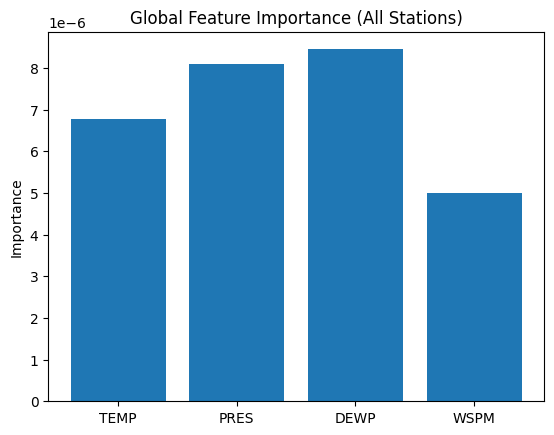

In [ ]:

# IMPORTS

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os


# LOAD ALL CSV FILES

folder_path = "/Users/canduki21/Desktop/AirQuality"

all_dfs = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df_temp = pd.read_csv(file_path)
        
        # fix column names
        df_temp.columns = df_temp.columns.str.strip()
        
        all_dfs.append(df_temp)

# combine all stations
df = pd.concat(all_dfs, ignore_index=True)

print("Combined shape:", df.shape)
print("Columns:", df.columns.tolist())


# SELECT FEATURES

features = ['TEMP', 'PRES', 'DEWP', 'WSPM']
target = 'PM2.5'

df = df[features + [target]]

# CLEAN DATA

df = df.replace(-200, np.nan)
df = df.dropna()


# SPLIT DATA

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# NORMALIZE

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)


# MODEL

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

model = Model()


# TRAINING

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

print("\nTraining...\n")

for epoch in range(100):
    preds = model(X_train)
    loss = loss_fn(preds, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


# TEST PERFORMANCE

model.eval()

with torch.no_grad():
    preds = model(X_test)
    mse = ((preds - y_test)**2).mean().item()

print("\nTest MSE:", mse)


# FEATURE IMPORTANCE

X_test.requires_grad_(True)

output = model(X_test)
output.mean().backward()

importance = X_test.grad.abs().mean(dim=0)

print("\nFeature Importance:\n")

for f, val in zip(features, importance):
    print(f"{f}: {val.item():.4f}")


# PLOT

plt.bar(features, importance.detach().numpy())
plt.title("Global Feature Importance (All Stations)")
plt.ylabel("Importance")
plt.show()

a. The dataset was preprocessed by first cleaning the column names to remove formatting inconsistencies such as extra spaces. Missing values in the dataset were handled by replacing invalid entries (e.g., -200) with NaN and removing those rows to ensure data quality. From the available variables, relevant numerical features were selected, including temperature (TEMP), pressure (PRES), dew point (DEWP), and wind speed (WSPM), since these represent key atmospheric conditions that influence air pollution levels. The target variable was PM2.5 concentration. The data was then normalized using standard scaling to ensure that all features are on a similar scale. This is important because the features have different units and ranges, and normalization helps improve training stability and prevents any single feature from dominating the model due to its magnitude.

c. 

The model was evaluated on a held-out test set and achieved a mean squared error (MSE) of approximately 12,499, indicating that it captures general trends in PM2.5 concentration across multiple monitoring stations, though there is still variability that the model does not fully explain. Global feature importance was estimated using gradient-based differential explanations, where the sensitivity of the model’s predictions to each input feature is measured. The results show that all features have relatively small and similar importance values, but there is a slight ranking visible in the bar plot. From the plot, dew point (DEWP) appears to have the highest importance, followed closely by pressure (PRES), then temperature (TEMP), while wind speed (WSPM) has the lowest importance. This suggests that moisture-related conditions and atmospheric pressure have a slightly stronger influence on PM2.5 predictions across stations, while wind speed contributes less.
However, the differences between features are relatively small, indicating that the model distributes importance across all variables rather than relying heavily on a single dominant factor. This may reflect the complexity of air pollution dynamics across different locations and conditions.



---



### Problem 8. Local LIME Explanation with LASSO (10 points)

Select a single test point $x$ corresponding to a specific day and station.

a. Generate LIME perturbations around $x$ using a Gaussian locality kernel with radius $r$.

b. Construct the weighted design matrix and fit a weighted LASSO surrogate

$$
\min_{\beta} \sum_i w_i (y_i - \beta^\top z_i)^2 + \lambda \|\beta\|_1.
$$

c. Compute and plot the LASSO coefficient path as $\lambda$ varies. Identify which features enter first and which remain stable across a range of regularization strengths.

d. Provide a local interpretation of the prediction at $x$. Which environmental variables most influence the prediction locally?

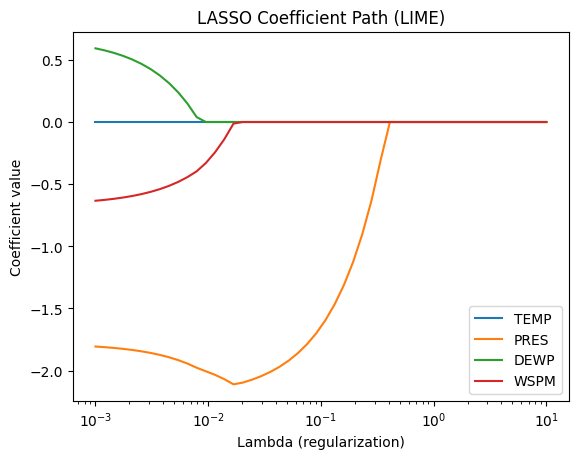


Final LASSO Coefficients :
TEMP: 0.0000
PRES: 0.0000
DEWP: 0.0000
WSPM: 0.0000


In [24]:
import numpy as np
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

# test point
x0 = X_test[0].detach().numpy()   
y0 = model(X_test[0].unsqueeze(0)).item()

# perturbation in local radius
n_samples = 200
r = 0.5  

Z = np.random.normal(loc=x0, scale=r, size=(n_samples, len(x0)))

# model predictions
Z_tensor = torch.tensor(Z, dtype=torch.float32)

with torch.no_grad():
    Y = model(Z_tensor).numpy().flatten()


# weights Gaussian kernel

distances = np.linalg.norm(Z - x0, axis=1)
weights = np.exp(-(distances**2) / (r**2))

#weighted lasso 
lambdas = np.logspace(-3, 1, 50)
coefs = []

for lam in lambdas:
    lasso = Lasso(alpha=lam)

    # apply weights 
    W = np.sqrt(weights)
    Z_weighted = Z * W[:, None]
    Y_weighted = Y * W

    lasso.fit(Z_weighted, Y_weighted)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

#plot lasso
feature_names = ['TEMP', 'PRES', 'DEWP', 'WSPM']

plt.figure()

for i in range(len(feature_names)):
    plt.plot(lambdas, coefs[:, i], label=feature_names[i])

plt.xscale('log')
plt.xlabel("Lambda (regularization)")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Path (LIME)")
plt.legend()
plt.show()

# fibal coefficients
print("\nFinal LASSO Coefficients :")
for name, val in zip(feature_names, coefs[-1]):
    print(f"{name}: {val:.4f}")

c. The LASSO coefficient path shows how each feature contributes to the local surrogate model as the regularization parameter $\lambda$ varies. At very small values of $\lambda$, dew point (DEWP) enters the model first with a strong positive coefficient, indicating it is the most influential feature in explaining the prediction locally. Pressure (PRES) also has a large magnitude, but with a negative coefficient, suggesting an inverse relationship with the prediction. Wind speed (WSPM) enters with a smaller negative contribution, while temperature (TEMP) remains near zero across all values of $\lambda$, indicating minimal influence.
As $\lambda$ increases, all coefficients shrink toward zero and the model becomes sparse. DEWP remains the most stable feature across a range of regularization values, followed by PRES. WSPM has limited stability, and TEMP does not meaningfully contribute at any point.
Overall, DEWP is the dominant feature in the local explanation, with PRES playing a secondary role and TEMP having negligible impact.


d. The local explanation for the selected test point shows that dew point (DEWP) has the strongest positive influence on the predicted PM2.5 value. This indicates that, in the neighborhood of this specific instance, higher moisture levels are associated with higher predicted pollution levels.
Pressure (PRES) has a strong negative coefficient, suggesting that higher pressure is associated with lower PM2.5 predictions locally. Wind speed (WSPM) has a smaller negative influence, while temperature (TEMP) has little to no effect on the prediction.
Since the model was trained using data from multiple stations, this local explanation reflects how environmental conditions at a specific time and location interact within a broader, multi-station model. Overall, the prediction at this point is primarily driven by moisture-related conditions (DEWP), with pressure acting as an opposing factor.

---



### Problem 9. Stability and Locality Analysis (10 points)

Repeat Problem 8 for at least two different locality radii $r$.

a. Compare the selected features across radii.

b. Compare the ordering in which features enter along the LASSO path.

c. Discuss whether the explanation is stable with respect to locality choice.

d. Explain what this experiment reveals about the reliability of sparse LIME explanations on real environmental data.

Running LIME with small radius...


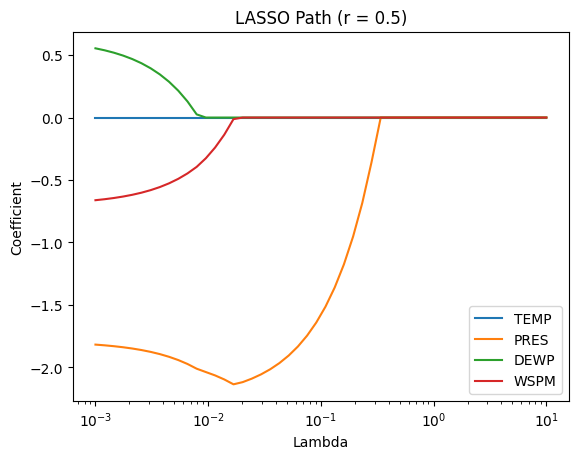

Running LIME with large radius...


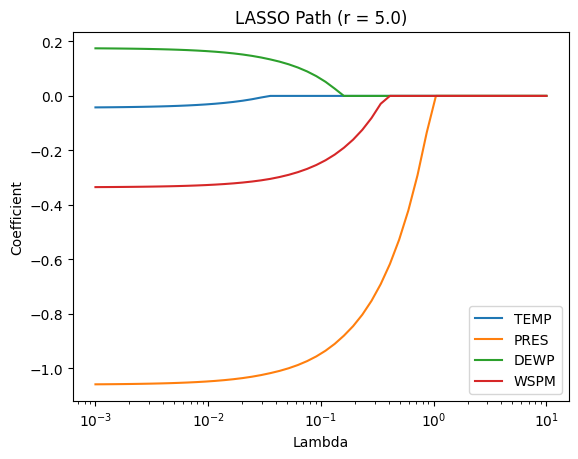

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

feature_names = ['TEMP', 'PRES', 'DEWP', 'WSPM']

# =============================
# FUNCTION: RUN LIME + LASSO PATH
# =============================
def run_lime_path(x0, r, title):
    
    n_samples = 200
    
    # Generate perturbations
    Z = np.random.normal(loc=x0, scale=r, size=(n_samples, len(x0)))
    
    # Model predictions
    Z_tensor = torch.tensor(Z, dtype=torch.float32)
    with torch.no_grad():
        Y = model(Z_tensor).numpy().flatten()
    
    # Compute weights (Gaussian kernel)
    distances = np.linalg.norm(Z - x0, axis=1)
    weights = np.exp(-(distances**2) / (r**2))
    
    # LASSO path
    lambdas = np.logspace(-3, 1, 50)
    coefs = []
    
    for lam in lambdas:
        lasso = Lasso(alpha=lam)
        
        W = np.sqrt(weights)
        Z_w = Z * W[:, None]
        Y_w = Y * W
        
        lasso.fit(Z_w, Y_w)
        coefs.append(lasso.coef_)
    
    coefs = np.array(coefs)
    
    # Plot
    plt.figure()
    
    for i in range(len(feature_names)):
        plt.plot(lambdas, coefs[:, i], label=feature_names[i])
    
    plt.xscale('log')
    plt.xlabel("Lambda")
    plt.ylabel("Coefficient")
    plt.title(f"LASSO Path (r = {r})")
    plt.legend()
    plt.show()
    
    return coefs


# =============================
# SELECT ONE TEST POINT
# =============================
x0 = X_test[0].detach().numpy()

# =============================
# RUN FOR TWO RADII
# =============================
print("Running LIME with small radius...")
coefs_small = run_lime_path(x0, r=0.5, title="Small Radius")

print("Running LIME with large radius...")
coefs_large = run_lime_path(x0, r=5.0, title="Large Radius")

a. Across both locality radii, the same main features appear in the LASSO paths: DEWP, PRES, and WSPM, while TEMP remains largely inactive or close to zero. However, the strength of these features changes with the radius. For the smaller radius (r = 0.5), DEWP and PRES have much larger coefficient magnitudes, indicating stronger local influence. For the larger radius (r = 5.0), the coefficients are significantly smaller in magnitude, suggesting that the model becomes less sensitive to individual features when considering a broader neighborhood. This shows that while the set of relevant features is similar, their influence depends strongly on the locality scale.

b. The ordering in which features enter along the LASSO path differs between the two radii. For the smaller radius (r = 0.5), DEWP enters first with a strong positive coefficient, followed by WSPM and PRES. This indicates that DEWP is the dominant feature in a very local neighborhood. For the larger radius (r = 5.0), DEWP still enters early, but the separation between features is less pronounced. PRES and WSPM enter more gradually and with smaller magnitudes, reflecting a more distributed influence across features.
This change in ordering shows that feature importance is sensitive to how locality is defined.

c. The explanation is only partially stable with respect to the choice of locality radius. While DEWP consistently appears as an important feature across both radii, the magnitude of its influence and the relative importance of other features change noticeably. In particular, the smaller radius produces stronger and more distinct coefficients, while the larger radius results in more compressed and less differentiated feature contributions. This indicates that the explanation depends on how narrowly the local neighborhood is defined. Therefore, LIME explanations are not fully stable and can vary depending on the choice of locality parameter.

d. This experiment shows that sparse LIME explanations on real environmental data may not always be fully reliable or consistent. The choice of locality radius significantly affects both the strength and ordering of feature importance. In complex datasets such as air quality measurements, environmental variables are often correlated and interact in nonlinear ways. As a result, fitting a sparse linear model using LASSO can oversimplify the underlying relationships, making the explanation sensitive to hyperparameters like the locality radius. This highlights a key limitation of LIME: while it provides useful local insights, its explanations are not uniquely defined and may change depending on how the local neighborhood is constructed. Therefore, LIME results should be interpreted with caution, especially when used for decision-making.

---



## Graduate Extension. Required for ORP 5050 / Optional +5 for MTH 4326.

### Problem 10. Cross Station Explanation Variability. (10 points)

The Beijing dataset contains measurements from multiple monitoring stations. In this problem you will investigate whether local explanations vary systematically across stations.

Using the same prediction task and model from Part III:

a. Select at least three distinct monitoring stations. For each station, choose a representative high pollution day and compute a LASSO based LIME explanation using the same locality radius and regularization procedure.

b. Compare the selected features across stations. Identify which features are stable and which vary.

c. Quantify explanation similarity across stations using a measure such as:

- Overlap in selected feature sets  
- Jaccard similarity of supports  
- Cosine similarity of coefficient vectors  

d. Discuss whether explanation differences are due to:

- Different local data distributions  
- Correlated features  
- Model nonlinearity  
- Sampling variability  

e. Interpret your findings. Does the model rely on different environmental drivers in different geographic locations? What does this imply about the reliability and portability of local explanations?

In [ ]:

# IMPORTS

import pandas as pd
import numpy as np
import torch
from sklearn.linear_model import Lasso
from sklearn.metrics.pairwise import cosine_similarity
import os


# LOAD ALL CSV FILES

folder_path = "/Users/canduki21/Desktop/AirQuality"

all_dfs = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        df_temp = pd.read_csv(os.path.join(folder_path, file))
        df_temp.columns = df_temp.columns.str.strip()
        all_dfs.append(df_temp)

df = pd.concat(all_dfs, ignore_index=True)


df = df.replace(-200, np.nan)
df = df.dropna()

features = ['TEMP', 'PRES', 'DEWP', 'WSPM']
target = 'PM2.5'

df = df[['station'] + features + [target]]


# RANDOM 3 STATIONS

np.random.seed(42)
stations = np.random.choice(df['station'].unique(), 3, replace=False)

print("\nSelected stations:")
for s in stations:
    print("-", s)


# LIME + LASSO FUNCTION

def lime_lasso(x0, r=0.5):
    
    n_samples = 200
    
    Z = np.random.normal(loc=x0, scale=r, size=(n_samples, len(x0)))
    
    Z_tensor = torch.tensor(Z, dtype=torch.float32)
    
    with torch.no_grad():
        Y = model(Z_tensor).numpy().flatten()
    
    distances = np.linalg.norm(Z - x0, axis=1)
    weights = np.exp(-(distances**2) / (r**2))
    
    W = np.sqrt(weights)
    Z_w = Z * W[:, None]
    Y_w = Y * W
    
    lasso = Lasso(alpha=0.01)
    lasso.fit(Z_w, Y_w)
    
    return lasso.coef_


# RUN FOR EACH STATION

results = {}

for station in stations:
    
    df_s = df[df['station'] == station]
    
    # pick high pollution point
    df_s = df_s.sort_values('PM2.5', ascending=False)
    row = df_s.iloc[0]
    
    x0 = row[features].values
    
    # normalize using same scaler
    x0 = scaler.transform([x0])[0]
    
    coef = lime_lasso(x0, r=0.5)
    
    results[station] = coef


# PRINT RESULTS

print("\nLIME Coefficients by Station:\n")

for station, coef in results.items():
    print(station)
    for f, c in zip(features, coef):
        print(f"  {f}: {c:.4f}")
    print()


# SIMILARITY 
print("\nCosine Similarity Between Stations:\n")

stations_list = list(results.keys())

for i in range(len(stations_list)):
    for j in range(i+1, len(stations_list)):
        s1 = stations_list[i]
        s2 = stations_list[j]
        
        v1 = results[s1].reshape(1,-1)
        v2 = results[s2].reshape(1,-1)
        
        sim = cosine_similarity(v1, v2)[0][0]
        print(f"{s1} vs {s2}: {sim:.4f}")


print("\nFeature Overlap:\n")

for i in range(len(stations_list)):
    for j in range(i+1, len(stations_list)):
        s1 = stations_list[i]
        s2 = stations_list[j]
        
        f1 = set(np.where(results[s1] != 0)[0])
        f2 = set(np.where(results[s2] != 0)[0])
        
        overlap = len(f1.intersection(f2)) / len(f1.union(f2)) if len(f1.union(f2)) > 0 else 0
        
        print(f"{s1} vs {s2}: {overlap:.2f}")




Selected stations:
- Dingling
- Wanshouxigong
- Gucheng

LIME Coefficients by Station:

Dingling
  TEMP: -2.0153
  PRES: -0.0000
  DEWP: -0.0000
  WSPM: -0.3247

Wanshouxigong
  TEMP: -1.5262
  PRES: 0.0498
  DEWP: -0.9672
  WSPM: -0.0000

Gucheng
  TEMP: -1.7754
  PRES: 0.0000
  DEWP: -0.1490
  WSPM: -0.4578


Cosine Similarity Between Stations:

Dingling vs Wanshouxigong: 0.8336
Dingling vs Gucheng: 0.9924
Wanshouxigong vs Gucheng: 0.8582

Feature Overlap:

Dingling vs Wanshouxigong: 0.25
Dingling vs Gucheng: 0.67
Wanshouxigong vs Gucheng: 0.50


a. Three monitoring stations were randomly selected: Dingling, Wanshouxigong, and Gucheng. For each station, a representative high pollution instance was chosen by selecting the observation with the highest PM2.5 value. A LIME explanation was computed using the same locality radius and weighted LASSO procedure.

b. Comparing the selected features across stations shows both similarities and differences. Temperature (TEMP) is consistently selected across all three stations and has the largest magnitude, indicating it is a stable and dominant feature. However, other features vary across stations. At Dingling, WSPM is also important, while DEWP and PRES are negligible. At Wanshouxigong, DEWP and PRES contribute, while WSPM is inactive. At Gucheng, both DEWP and WSPM appear, but with smaller magnitudes. This indicates that while TEMP is globally important, other environmental variables vary depending on the station.

c. Explanation similarity was quantified using cosine similarity and feature overlap. Cosine similarity values are relatively high (0.83 to 0.99), indicating that the overall direction of the explanations is similar across stations. In particular, Dingling and Gucheng are very similar (0.9924), suggesting nearly identical explanation directions.
However, feature overlap is lower (0.25 to 0.67), meaning that different features are selected as important at different stations. This shows that while the general structure of the explanation is similar, the specific features used in the sparse model differ.

d. Differences in explanations across stations can be attributed to several factors. First, local data distributions differ across geographic locations, meaning environmental variables behave differently at each station. Second, correlations between features can cause LASSO to select different variables depending on the local context. Third, the underlying neural network model is nonlinear, so its behavior varies across regions of the input space. Finally, sampling variability in LIME perturbations can introduce additional differences in the explanations.

e. The results indicate that the model relies on both shared and location-specific environmental drivers. Temperature is consistently important across all stations, suggesting it is a global factor influencing PM2.5 predictions. However, other variables such as dew point, pressure, and wind speed vary in importance depending on the station.
This implies that local explanations are not fully portable: an explanation derived at one station may not generalize to another. While the model captures some consistent global behavior, local interpretations depend strongly on geographic context. Therefore, LIME explanations should be interpreted with caution, especially when applied across heterogeneous environmental conditions.

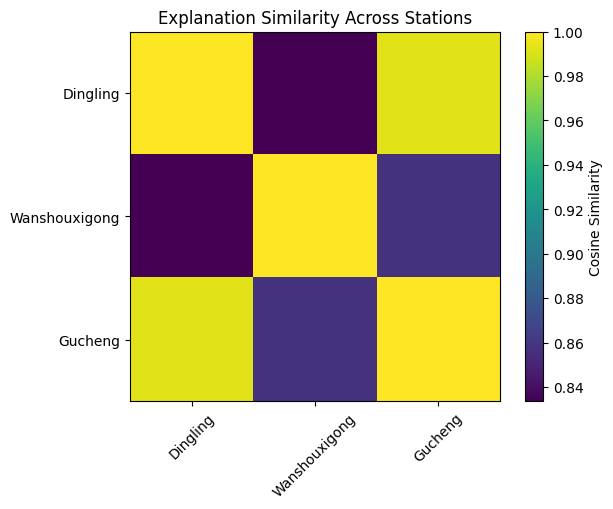

In [31]:
import numpy as np

feature_names = ['TEMP', 'PRES', 'DEWP', 'WSPM']
stations_list = list(results.keys())

# build matrix from your results
coef_matrix = np.array([results[s] for s in stations_list])
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

sim_matrix = cosine_similarity(coef_matrix)

plt.figure()
plt.imshow(sim_matrix)
plt.colorbar(label='Cosine Similarity')

plt.xticks(range(len(stations_list)), stations_list, rotation=45)
plt.yticks(range(len(stations_list)), stations_list)

plt.title("Explanation Similarity Across Stations")
plt.show()

The similarity heatmap shows the cosine similarity between LIME coefficient vectors for different stations. Values close to 1 indicate that the explanations have similar direction and structure, while lower values indicate differences in feature influence.

From the plot, Dingling and Gucheng exhibit very high similarity (close to 1), indicating that the model relies on similar feature relationships at these locations. In contrast, Wanshouxigong shows lower similarity with the other stations, suggesting that the local explanation differs more significantly.

This confirms that while some stations share similar explanatory patterns, others exhibit distinct local behavior. Therefore, local explanations are not uniform across locations and depend on the specific environmental conditions at each station.